Mia Kim  
Dr. Roberto Vargas  
85-432/732 Data Science for Psychology and Neuroscience

# Predicting Overall Hospital Ratings From Demographic and Performance Data

# Background

Hospital ratings are important predictors of health outcomes. They have the ability to influence patients' decisions about where to access healthcare as well as hospital policies and reputations. As such, understanding how these ratings are calculated and what factors drive them is important not just for healthcare administrators, but for patients, providers, and researchers. 

The Centers for Medicare and Medicaid Services (CMS) measure Overall Hospital Ratings on a five-star scale combining categorical summary scores into one overall score. Categorical summary scores include patient mortality, safety, readmission, and experience -- each weighted as 22% of the overall score -- as well as timeliness and effectiveness of care, weighted as 12% of the overall score. [$^1$](https://data.cms.gov/provider-data/topics/hospitals/overall-hospital-quality-star-rating)

This analysis is conducted using a combination of these performance metrics as well as several demographic factors, such as the hospital's ownership type and the U.S. state in which it is located. The combination of these categories will hopefully provide a better look into how overall hospital ratings are determined by CMS and allow patients to be more informed in their decisions. 

# Variables

All observations and variables were collected by CMS's [Provider Data Catalog](https://data.medicare.gov/data/hospital-compare) and uploaded to [Kaggle](https://www.kaggle.com/datasets/center-for-medicare-and-medicaid/hospital-ratings/data). The raw dataset contained 4,812 total observations and 28 variables. After data cleaning (described below), 2,301 observations and 13 variables remained, all of which are numeric. 

### Demographic Measures
`State`: U.S. state in which the given hospital is located, encoded in alphabetical order (1 = Alabama, 50 = Wyoming)

`Hospital.Type`: Type of hospital (1 = Acute Care, 2 = Children's, 3 = Critical Access)

`Hospital.Ownership`: Ownership classification of the given hospital  
&nbsp;&nbsp;&nbsp;&nbsp;1 = Government - Federal  
&nbsp;&nbsp;&nbsp;&nbsp;2 = Hospital District or Authority  
&nbsp;&nbsp;&nbsp;&nbsp;3 = Government - Local  
&nbsp;&nbsp;&nbsp;&nbsp;4 = Government - State  
&nbsp;&nbsp;&nbsp;&nbsp;5 = Physician  
&nbsp;&nbsp;&nbsp;&nbsp;6 = Proprietary  
&nbsp;&nbsp;&nbsp;&nbsp;7 = Tribal  
&nbsp;&nbsp;&nbsp;&nbsp;8 = Voluntary non-profit - Church  
&nbsp;&nbsp;&nbsp;&nbsp;9 = Voluntary non-profit - Other  
&nbsp;&nbsp;&nbsp;&nbsp;10 = Voluntary non-profit - Private 

`Emergency.Services`: Indicates whether a hospital has an Emergency Service department (1 = No, 2 = Yes)

`EHRmeaningfuluse`: Indicates whether Electronic Health Records (EHR) are meaningfully used (1 = No, 2 = Yes)

### Rating Measures
`Hospital.overall.rating`: Overall rating of a given hospital based on the hospital's mortality, safety of care, readmission, patient experience, effectiveness of care, timeliness of care, and efficient use of medical equipment.
Scale: 1 (lowest) to 5 (highest)

`Mortality`: How the given hospital's mortality rate compares to the national average (1 = Above, 2 = Below, 3 = Same)

`Safetyofcare`: How the given hospital's safety of care rating compares to the national average (1 = Above, 2 = Below, 3 = Same)

`Readmission`: How the given hospital's readmission rate compares to the national average (1 = Above, 2 = Below, 3 = Same)

`PatientExp`: How the given hospital's patient experience rating compares to the national average (1 = Above, 2 = Below, 3 = Same)

`CareEffectiveness`: How the given hospital's effectiveness of care rating compares to the national average (1 = Above, 2 = Below, 3 = Same)

`CareTimely`: How the given hospital's timeliness of care rating compares to the national average (1 = Above, 2 = Below, 3 = Same)

`MedImaging`: How the given hospital's efficiency of using medical equipment rating compares to the national average (1 = Above, 2 = Below, 3 = Same)

# Hypotheses
The null hypothesis ($H_0$) of this analysis is that no predictor variables (State, Hospital Ownership, Emergency Services, Meaningful use of EHRs, Mortality, Safety of Care, Readmission, Patient Experience, Effectiveness of Care, Timeliness of Care, Efficient Use of Medical Imaging) will significantly affect the Overall Hospital Rating.

In other words:
\begin{aligned}
Y &= \beta_0 + \beta_1 \cdot \text{State} + \beta_2 \cdot \text{Hospital Ownership} + \beta_3 \cdot \text{Emergency Services} \\
  &\quad + \beta_4 \cdot \text{Meaningful use of EHRs} + \beta_5 \cdot \text{Mortality} + \beta_6 \cdot \text{Safety of Care} \\
  &\quad + \beta_7 \cdot \text{Readmission} + \beta_8 \cdot \text{Patient Experience} + \beta_9 \cdot \text{Effectiveness of Care} \\
  &\quad + \beta_{10} \cdot \text{Timeliness of Care} + \beta_{11} \cdot \text{Efficient Use of Medical Imaging} + \epsilon
\end{aligned}
where all $\beta_n = 0$.

The alternative hypothesis ($H_A$) of this analysis is that there is at least one predictor variable significantly associated with Overall Hospital Rating such that at least one $\beta_n \neq 0$.

# Data Organization

The dataset is structured such that each row represents an individual hospital and each column represents a variable describing the hospital. These variables included demographic variables such as `Hospital.Name`, `Hospital.Ownership`, and `Address`, as well as descriptive variables such as `Hospital.overall.rating`, `Mortality`, and `EHRmeaningfuluse`. 

# Data Cleansing & Tidying

Hospitals with data marked as "Not Available" or simply empty cells were removed, along with variables irrelevant to the analysis. These variables included:
- `Provider.ID`
- `Hospital.Name`(removed after being used in an initial visualization)
- `Address`
- `City`
- `ZIP.Code`
- `County.Name`
- `Phone.Number`
- All footnote columns

Rating measures were also renamed for clarity and all categorical variables were converted from character data types to numeric data types as described in the Variables section. The code used to perform these steps is included and commented below, along with the first few rows of the cleaned dataset (`data`).

In [142]:
library(tidyverse)

# Load raw data
rawdata = read.csv("Hospital General Information.csv")

data <- rawdata %>% 

  # Remove missing data
  filter(Hospital.overall.rating != "Not Available" &
         Mortality.national.comparison != "Not Available" &
         Safety.of.care.national.comparison != "Not Available" &
         Readmission.national.comparison != "Not Available" &
         Patient.experience.national.comparison != "Not Available" &
         Effectiveness.of.care.national.comparison != "Not Available" &
         Timeliness.of.care.national.comparison != "Not Available" &
         Efficient.use.of.medical.imaging.national.comparison != "Not Available"
  ) %>% 

  # Remove irrelevant variables
  dplyr::select(-Provider.ID,
                -Address,
                -City,
                -ZIP.Code,
                -County.Name,
                -Phone.Number,
                -ends_with(".footnote")
  ) %>% 

  # Rename variables for clarity
  rename(EHRmeaningfuluse = Meets.criteria.for.meaningful.use.of.EHRs,
         Mortality = Mortality.national.comparison,
         Safetyofcare = Safety.of.care.national.comparison,
         Readmission = Readmission.national.comparison,
         PatientExp = Patient.experience.national.comparison,
         CareEffectiveness = Effectiveness.of.care.national.comparison,
         CareTimely = Timeliness.of.care.national.comparison,
         MedImaging =  Efficient.use.of.medical.imaging.national.comparison
  ) %>% 

  # Change variable types from character to numeric
  mutate(Hospital.Type = as.numeric(factor(Hospital.Type)),
         Hospital.Ownership = as.numeric(factor(Hospital.Ownership)),
         Emergency.Services = as.numeric(factor(Emergency.Services)),
         EHRmeaningfuluse = as.numeric(factor(EHRmeaningfuluse)),
         Hospital.overall.rating = as.numeric(factor(Hospital.overall.rating)),
         Mortality = as.numeric(factor(Mortality)),
         Safetyofcare = as.numeric(factor(Safetyofcare)),
         Readmission = as.numeric(factor(Readmission)),
         PatientExp = as.numeric(factor(PatientExp)),
         CareEffectiveness = as.numeric(factor(CareEffectiveness)),
         CareTimely = as.numeric(factor(CareTimely)),
         MedImaging = as.numeric(factor(MedImaging))
  )

# Cleaned dataset
head(data)

,Hospital.Name,State,Hospital.Type,Hospital.Ownership,Emergency.Services,EHRmeaningfuluse,Hospital.overall.rating,Mortality,Safetyofcare,Readmission,PatientExp,CareEffectiveness,CareTimely,MedImaging
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SOUTHEAST ALABAMA MEDICAL CENTER,AL,1,2,2,2,3,3,1,3,2,3,3,3
2,MARSHALL MEDICAL CENTER SOUTH,AL,1,2,2,2,3,2,3,1,3,3,1,2
3,ELIZA COFFEE MEMORIAL HOSPITAL,AL,1,2,2,2,2,2,3,3,2,3,1,3
4,ST VINCENT'S EAST,AL,1,9,2,2,2,3,2,3,2,2,3,3
5,DEKALB REGIONAL MEDICAL CENTER,AL,1,6,2,2,3,2,3,3,3,3,1,3
6,SHELBY BAPTIST MEDICAL CENTER,AL,1,9,2,2,3,3,1,1,2,3,2,2


# Data Visualizations

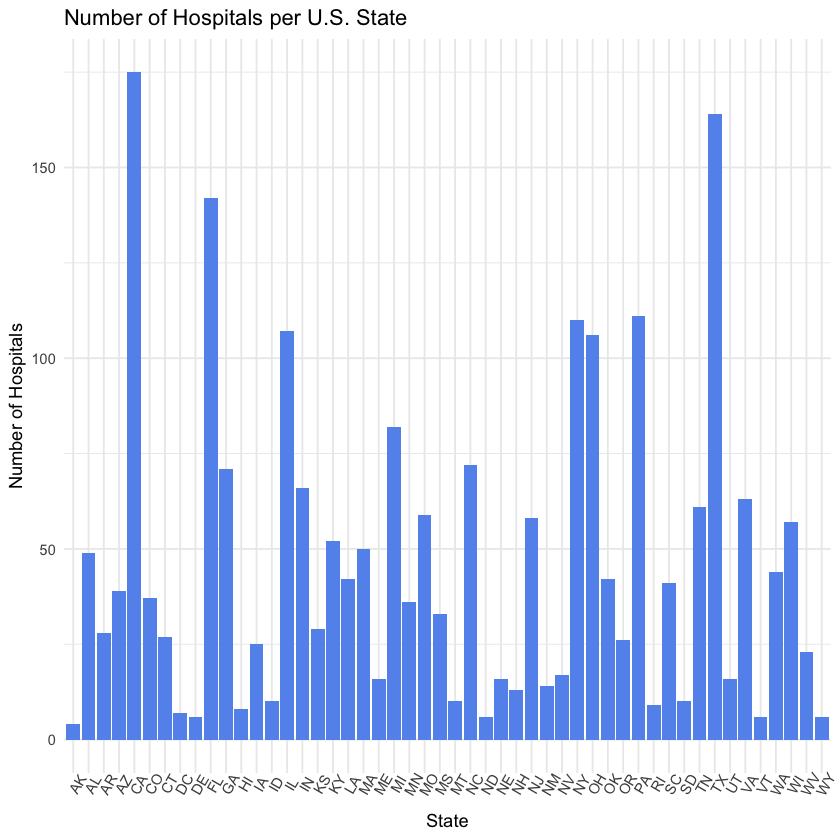

In [143]:
# Group data by U.S. State and count
geodata <- data %>%
  group_by(State) %>%
  count(Hospital.Name)

# Graph data
ggplot(geodata, aes(x = State, y = n)) +
  geom_col(fill = 'cornflower blue') +
  labs(title = "Number of Hospitals per U.S. State", x = "State", y = "Number of Hospitals") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 60))

### Figure 1: Number of Hospitals per U.S. State
This bar plot shows the number of hospitals in each U.S. State contained in this dataset after cleaning. As expected, states with larger populations, such as California, Florida, and Texas, have the highest number of hospitals, while states with smaller populations like Alaska, South Carolina, and Delaware have the lowest number of hospitals.

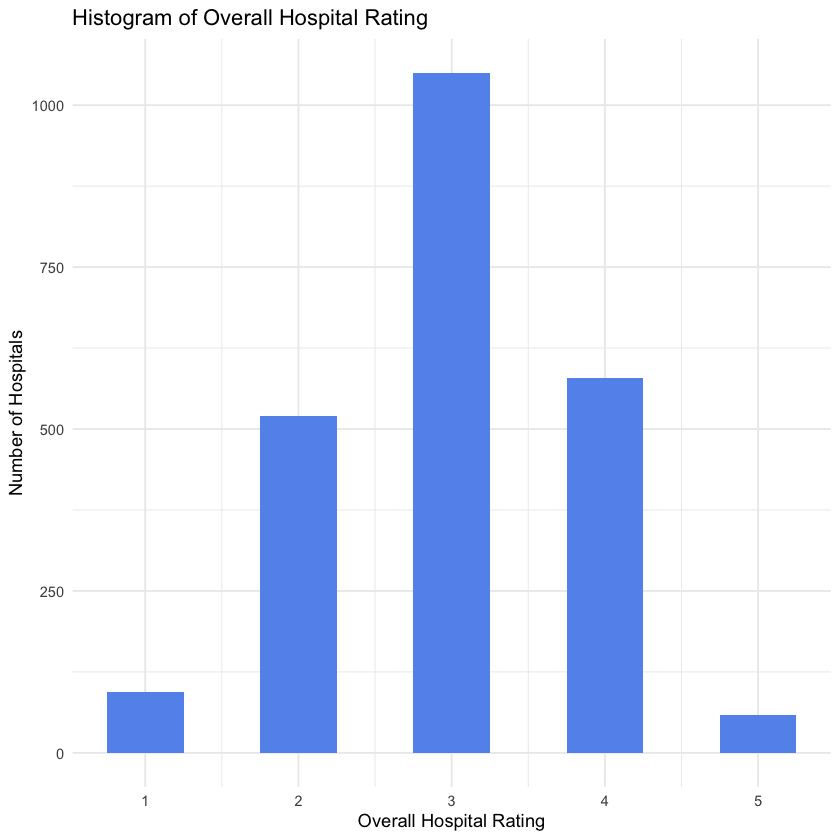

In [144]:
# Remove `Hospital.Name` for the rest of the analysis and convert `State` to numerical data type
cleandata <- data %>%
    select(-Hospital.Name) %>%
    mutate(State = as.numeric(factor(State)))

# Graph Overall Hospital Rating Histogram
ggplot(cleandata, aes(x = Hospital.overall.rating)) +
  geom_histogram(fill = 'cornflower blue', binwidth = 0.5) +
  labs(title = "Histogram of Overall Hospital Rating", x = "Overall Hospital Rating", y = "Number of Hospitals") +
  theme_minimal()

### Figure 2: Histogram of Overall Hospital Rating
This histogram shows the distribution of overall hospital ratings (`Hospital.overall.rating`) included in the dataset. The ratings appear to be normally distributed and are centered at a mean of 2.995 ± 0.862. This suggests most hospitals receive a moderate score, with slightly more ratings of 4 than 2 and 1 than 5.

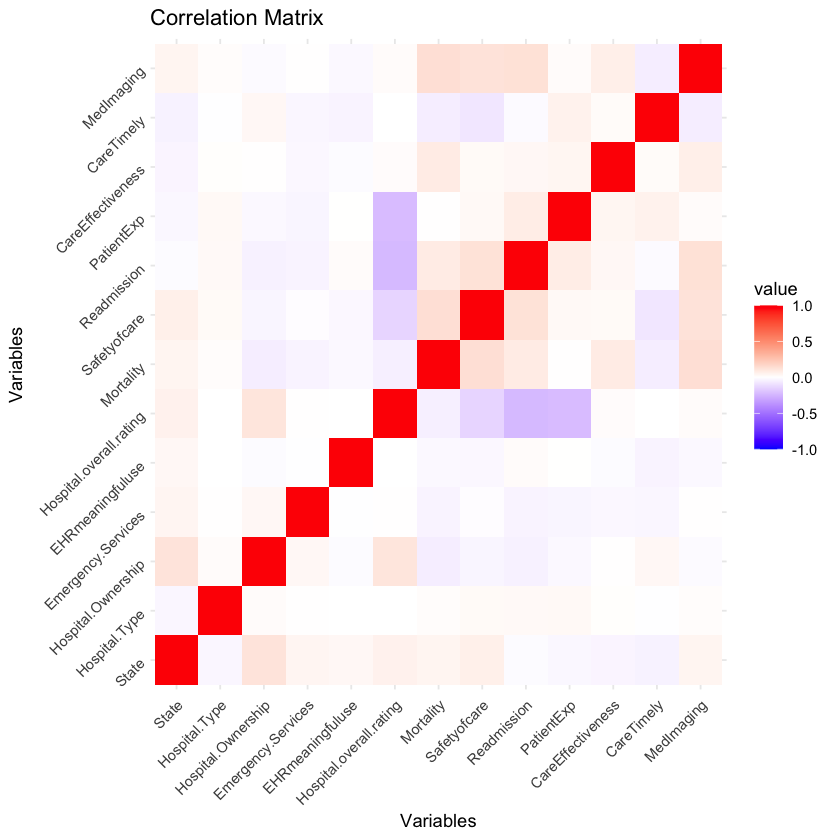

In [146]:
library(reshape2)

# Calculate correlation matrix 
cormat <- cor(cleandata)

# Melt correlation matrix for plotting
meltcormat <- melt(cormat)

# Plot correlation matrix in a heatmap
ggplot(meltcormat, aes(x = Var1, y = Var2, fill = value)) +
    geom_tile() +
    scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0, limit = c(-1, 1)) +
    theme_minimal() +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        axis.text.y = element_text(angle = 45, hjust = 1)
    ) +
    labs(title = "Correlation Matrix",
        x = "Variables",
        y = "Variables")

### Figure 3: Correlation Matrix of Prediction Variables for the Overall Hospital Rating
This correlation matrix displays the relationships between all variables in the cleaned dataset. Positive correlations are represented with red, negative correlations are blue, and neutral or zero correlations are white. The strongest correlations were between Patient Experience and Overall Hospital Rating, and Readmission and Overall Hospital Rating; however, all observed correlations are below 0.3. Due to the lack of strong multicolinearity, a multiple linear regression model is appropriate.

# Data Analyses 

In [147]:
# Fit linear regression model of overall hospital ratings against all variables.
regressionmod <- lm(Hospital.overall.rating ~ ., data = cleandata)
summary(regressionmod)


Call:
lm(formula = Hospital.overall.rating ~ ., data = cleandata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.23777 -0.61148  0.07444  0.54146  2.04297 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)         3.2546223  1.2744147   2.554  0.01072 *  
State               0.0026949  0.0011961   2.253  0.02434 *  
Hospital.Type       0.5119369  0.8093039   0.633  0.52708    
Hospital.Ownership  0.0332868  0.0076948   4.326 1.58e-05 ***
Emergency.Services -0.1222254  0.1309452  -0.933  0.35071    
EHRmeaningfuluse    0.0352438  0.4678921   0.075  0.93996    
Mortality          -0.0263148  0.0228593  -1.151  0.24978    
Safetyofcare       -0.1158600  0.0203958  -5.681 1.51e-08 ***
Readmission        -0.2211734  0.0209805 -10.542  < 2e-16 ***
PatientExp         -0.2269629  0.0215303 -10.542  < 2e-16 ***
CareEffectiveness   0.0496142  0.0342495   1.449  0.14758    
CareTimely         -0.0006742  0.0216898  -0.031  0.97521    
MedImagi

### Figure 4: Multiple Linear Regression Model of Predictor Variables
This multiple linear regression model was used to predict Overall Hospital Ratings based on the predictor variables in the dataset. The null hypothesis for this test is that there is no relationship between the predictor variables and the Overall Hospital Rating such that the predictor variables do not affect the Overall Hospital Rating.

This model shows several variables with p-values that are less than $\alpha = 0.05$, such that they may have an effect on the Overall Hospital Rating:
- State ($p = 0.02434$)
- Hospital Ownership ($p = 1.58\cdot 10^{-5}$)
- Safety of Care ($p = 1.51\cdot 10^{-8}$)
- Readmission ($p = < 2\cdot 10^{-16}$)
- Patient Experience ($p = < 2\cdot 10^{-16}$)
- Efficient Use of Medical Imaging Equipment ($p = 0.00305$)

The strong significance of Readmission and Patient Experience in this model reinforces the correlation discovered in the correlation matrix calculated earlier.

(Intercept)              State      Hospital.Type Hospital.Ownership 
       4.455366163        0.000372788        0.049664654        0.007674341 
Emergency.Services   EHRmeaningfuluse          Mortality       Safetyofcare 
       0.179317779        0.968986227        0.047324887        0.013339218 
       Readmission         PatientExp  CareEffectiveness         CareTimely 
       0.015984764        0.023421026        0.020733574        0.010456897 
        MedImaging 
       0.038314544

(Intercept)              State      Hospital.Type Hospital.Ownership 
       3.254622260        0.002694905        0.511936902        0.033286752 
Emergency.Services   EHRmeaningfuluse          Mortality       Safetyofcare 
      -0.122225419        0.035243837       -0.026314809       -0.115859986 
       Readmission         PatientExp  CareEffectiveness         CareTimely 
      -0.221173384       -0.226962915        0.049614232       -0.000674201 
        MedImaging 
       0.068616931

[1] 0.98

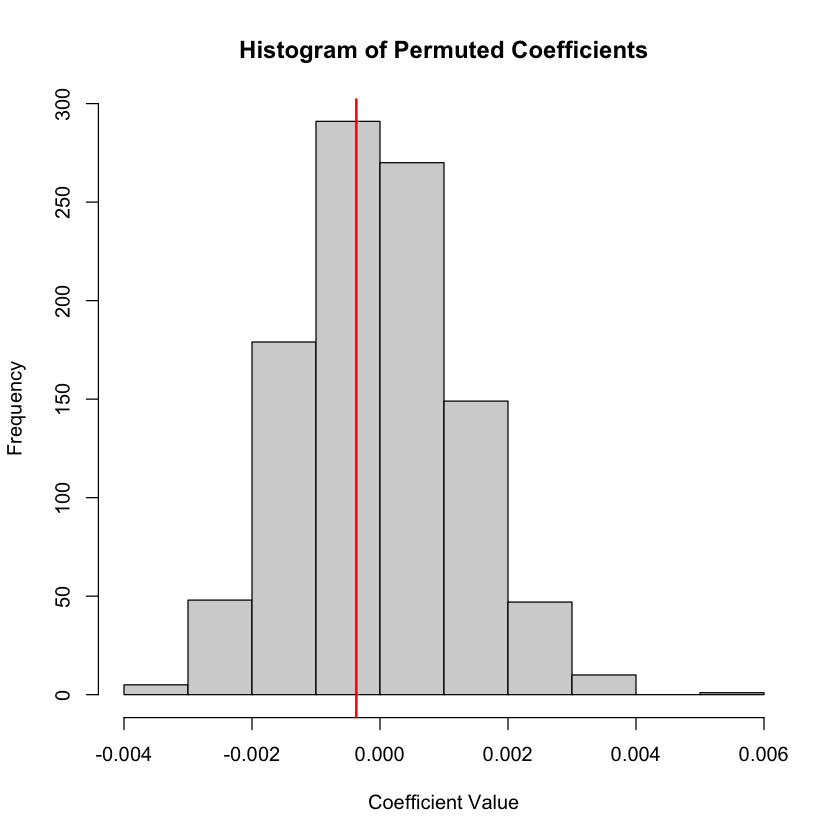

In [148]:
permdata = cleandata

R = 1000

# Initialize results matrix
perm.coefs=matrix(NA, nrow=R, ncol=13)

# for loop conducting permutation test
for (i in 1:R){
    permdata$Hospital.overall.rating=data$Hospital.overall.rating[sample(nrow(cleandata))]
    model = lm(Hospital.overall.rating ~ ., data = permdata)
    perm.coefs[i,]=coef(model)
}

# Absolute value of coefficients
abs(coef(model))

# Plot histogram of permuted coefficients with a red line representing the true coefficients from the original data
hist(perm.coefs[,2], main = "Histogram of Permuted Coefficients", xlab = "Coefficient Value")
abline(v = -0.0003699342, col = 'red', lwd = 2)

# Fit original data to permuted data
perm.real = coef(lm(Hospital.overall.rating ~ ., data = cleandata))
perm.real

# Calculate p-value
perm.p = sum(perm.coefs[,2] < perm.real[2]) / R
perm.p

### Figure 5: Permutation Test 

This histogram compares the true coefficient obtained from the original linear model to the distribution of coefficients generated by the permutation model. The red line marks the value of the true coefficient, while the histogram distribution shows the relationship between the predictors and the outcome assuming no relationship. Because the original coefficient aligns well with the permutated distribution, it likely is not statistically significant. This is supported by the permutation p-value (0.975) and indicates the predictor variables do not have significant effects on the Overall Hospital Rating.

In [149]:
library(boot)

# Initialize results dataframe
results <- data.frame(actual = integer(nrow(cleandata)), predicted = rep(NA, nrow(cleandata)))

# for loop for Leave One Out Cross Validation (LOOCV)
for (i in 1:nrow(cleandata)){
    train_data <- cleandata[-i, ]
    test_data <- cleandata[i, , drop = FALSE]

    logm <- lm(Hospital.overall.rating ~ ., data = train_data)

    probability <- as.numeric(predict(logm, newdata = test_data))

    predicted_class <- pmin(pmax(round(probability), 1), 5)

    results$actual[i] <- test_data$Hospital.overall.rating
    results$predicted[i] <- predicted_class
}

head(results)

# Calculate error rate
incorrect <- sum(results$actual != results$predicted)
error_rate <- incorrect / nrow(results)
error_rate

Warning message in predict.lm(logm, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


,actual,predicted
,<dbl>,<dbl>
1,3,3
2,3,3
3,2,3
4,2,3
5,3,2
6,3,3


[1] 0.5532377

### Leave-One-Out Cross Validation
Leave-One-Out Cross Validation (LOOCV) was used to evaluate the predictive accuracy of the multiple linear regression model performed above on the Overall Hospital Rating. The model misclassified 1,273 predictions with an error rate of 55.32%. This indicates the model's prediction strength may be limited. 

Some difficulties were encountered during model fitting as shown by the existing rank deficiency warning message. As the earlier correlation matrix showed no strong multicolinearity, this issue is likely caused by the non-binary outcome variable or `State` and `Hospital.Ownership` having a large number of levels. However, removing these variables did not significantly effect the error rate of the LOOCV so they were kept in the analysis.

# Conclusions
Give the results from the multiple linear regression model, permutation test, and LOOCV, several predictor variables have a significant effect on the Overall Hospital Rating. The multiple linear regression model suggests that State, Hospital Ownership, Safety of Care, Readmission, Patient Experience, and  Efficient Use of Medical Imaging were significant predictors; however, the permutation test contradicts these results, suggesting observed coefficients do not significantly differ from those obtained by random chance. Furthermore, while the LOOCV model showed some significance, its high error error rate of 55.32% indicates limitations in its accuracy. Overall, these findings highlight the complexity of hospital rating prediction. While certain factors appear to have larger influences on the overall predictions than others, it is clear the rating system is more complex and likely influenced by additional factors that were unaccessed during this analysis.